# Electricity demand forecasting with covariates

This notebook ports the upstream NumPyro electricity demand example to the PyMC API.
We forecast **hourly electricity demand in Victoria (Australia)** with a random-walk
local level, daily and weekly Fourier seasonality, a **temperature covariate**, and a
Student-T likelihood.

The series is the Victoria electricity demand data from the TensorFlow Probability
structural-time-series case study (originally from Hyndman & Athanasopoulos,
*Forecasting: Principles and Practice*): the first eight weeks of 2014, sampled hourly,
together with the aligned temperature series. Summer heat drives air-conditioning load,
so temperature is a strong — and nonlinear — driver of demand. The upstream notebook
models the temperature response with a Hilbert-space Gaussian process; here we keep the
example lean with a quadratic response, which already captures the U-shaped relationship.

Because the model has real covariates, forecasting works by passing **full-horizon
covariates** to `Forecaster.forecast` (rather than `horizon=`): the temperature over the
forecast window is treated as known, as is standard in electricity load forecasting
(in production one would plug in a weather forecast).

## Prepare notebook

In [1]:
import logging
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from pymc_forecast import (
    Forecaster,
    ForecastingModel,
    Horizon,
    build_model,
    evaluate_forecast,
    fourier_features,
)
from pymc_forecast.data import FUTURE_DIM, TIME_DIM
from pymc_forecast.datasets import load_victoria_electricity

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)

SEED = 42

# CI executes every example notebook end-to-end with reduced settings.
SMOKE_TEST = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
NUM_STEPS = 300 if SMOKE_TEST else 30_000
NUM_SAMPLES = 50 if SMOKE_TEST else 1_000

## Read data

`load_victoria_electricity` returns two aligned hourly series with a real
`DatetimeIndex` coordinate: demand (GW) and temperature (°C).

hourly observations: 1344


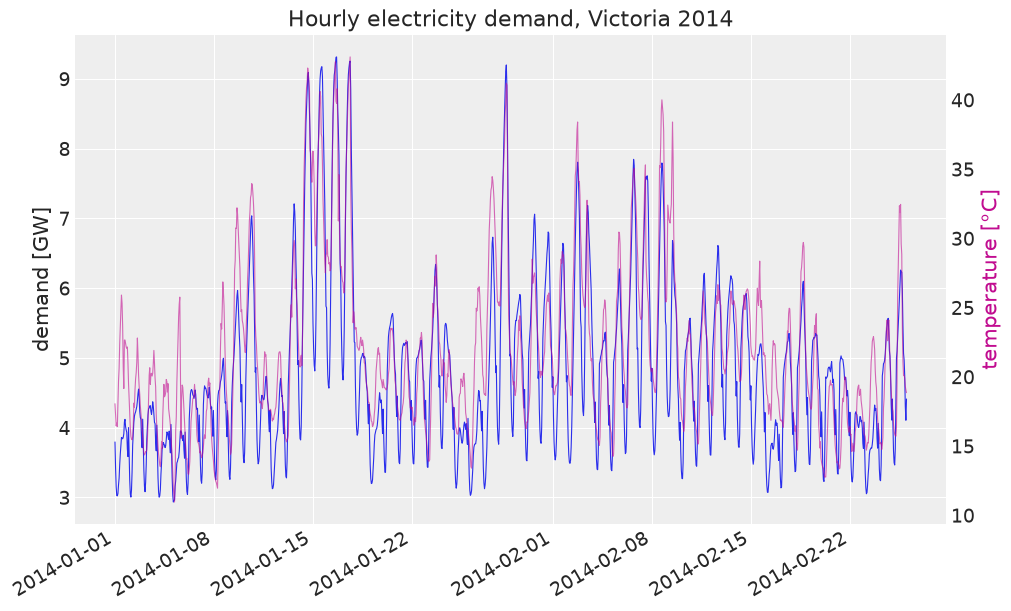

In [2]:
demand, temperature = load_victoria_electricity()
duration = demand.sizes[TIME_DIM]
time_values = demand[TIME_DIM].values
print("hourly observations:", duration)

fig, ax = plt.subplots()
ax.plot(time_values, demand.values, color="C0", lw=0.8)
ax.set(title="Hourly electricity demand, Victoria 2014", ylabel="demand [GW]")
ax_temp = ax.twinx()
ax_temp.plot(time_values, temperature.values, color="C3", lw=0.8, alpha=0.6)
ax_temp.set_ylabel("temperature [°C]", color="C3")
ax_temp.grid(False)
fig.autofmt_xdate()
plt.show()

The demand spikes line up with the temperature spikes: hot summer days push
air-conditioning load. A scatter plot makes the shape of that relationship explicit.

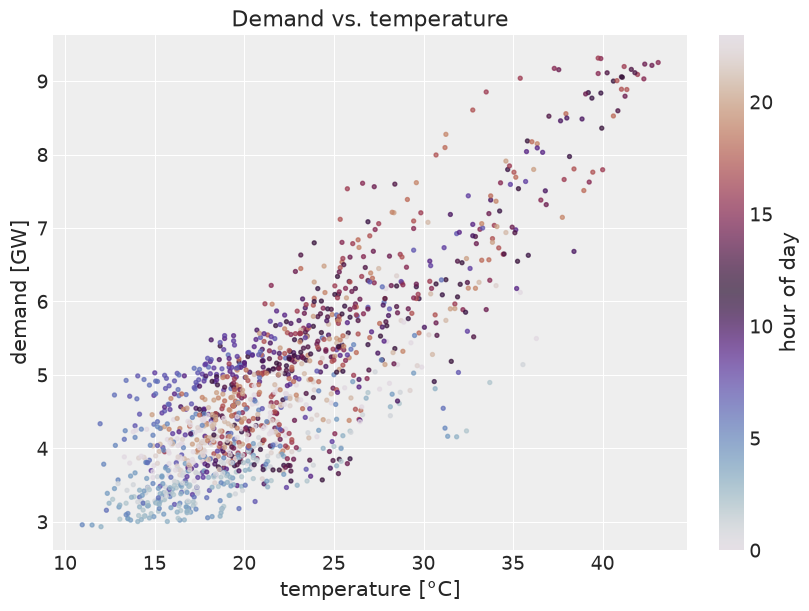

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    temperature.values,
    demand.values,
    c=demand[TIME_DIM].dt.hour.values,
    cmap="twilight",
    s=8,
    alpha=0.7,
)
fig.colorbar(scatter, ax=ax, label="hour of day")
ax.set(title="Demand vs. temperature", xlabel="temperature [°C]", ylabel="demand [GW]")
plt.show()

The response is clearly nonlinear: demand is flat below ~25 °C and rises steeply above.
A quadratic in (standardized) temperature is the simplest curve that captures this bend.

## Train-test split

Hold out the final week (168 hours). All slicing is by the labeled time dim; the
`DatetimeIndex` coordinates flow through to the forecast output.

In [4]:
TEST_HOURS = 24 * 7
T1 = duration - TEST_HOURS

y_train = demand.isel({TIME_DIM: slice(None, T1)})
y_test = demand.isel({TIME_DIM: slice(T1, None)})
print("train:", y_train.sizes[TIME_DIM], "test:", y_test.sizes[TIME_DIM])

train: 1176 test: 168


## Design matrix

The covariates combine daily and weekly Fourier harmonics with the standardized
temperature and its square, all labeled along a `"covariate"` dim. Standardization uses
**training-window statistics only**, so no test information leaks into the features.

In [5]:
hours = np.arange(duration)
daily = fourier_features(hours, period=24.0, num_terms=4)
weekly = fourier_features(hours, period=24.0 * 7, num_terms=3)

temp_mean = float(temperature.isel({TIME_DIM: slice(None, T1)}).mean())
temp_scale = float(temperature.isel({TIME_DIM: slice(None, T1)}).std())
temp_z = (temperature.values - temp_mean) / temp_scale

columns = {
    **{f"daily_{label}": daily.sel(fourier=label).values for label in daily["fourier"].values},
    **{f"weekly_{label}": weekly.sel(fourier=label).values for label in weekly["fourier"].values},
    "temperature": temp_z,
    "temperature_sq": temp_z**2,
}
covariates = xr.DataArray(
    np.column_stack(list(columns.values())),
    dims=(TIME_DIM, "covariate"),
    coords={TIME_DIM: time_values, "covariate": list(columns)},
)
covariates_train = covariates.isel({TIME_DIM: slice(None, T1)})
print("covariates:", dict(covariates.sizes))

covariates: {'time': 1344, 'covariate': 16}


## Model specification

The mean has four pieces: a global intercept, a random-walk local level (non-centered,
as in the univariate example), the Fourier seasonality, and the quadratic temperature
response — the last three all flowing through one regression on the labeled covariates.
A Student-T likelihood absorbs the occasional demand spike the mean structure misses.

As always in `pymc_forecast`, one model body serves training and forecasting: the
random-walk drift gets a separate `drift_raw_future` variable on the forecast horizon
via `time_series`, and `predict` registers the observed `obs` prefix and the
`forecast` suffix.

In [6]:
class ElectricityDemand(ForecastingModel):
    """Local level + Fourier seasonality + quadratic temperature response."""

    def model(self, h: Horizon, covariates: xr.DataArray) -> None:
        bias = pm.Normal("bias", 0.0, 10.0)
        weight = pm.Normal("weight", 0.0, 1.0, dims="covariate")
        drift_scale = pm.LogNormal("drift_scale", -20.0, 5.0, initval=0.01)
        nu = pm.Gamma("nu", alpha=10.0, beta=2.0)
        sigma = pm.LogNormal("sigma", -5.0, 5.0, initval=0.05)

        drift_raw = self.time_series(
            "drift_raw",
            lambda name, dims: pm.Normal(name, 0.0, 1.0, dims=dims),
        )
        level = pt.cumsum(drift_raw * drift_scale)
        regression = pt.dot(covariates.values, weight)

        self.predict(
            lambda name, mu, dims, observed: pm.StudentT(
                name,
                nu=nu,
                mu=mu,
                sigma=sigma,
                dims=dims,
                observed=observed,
            ),
            bias + level + regression,
        )


model = ElectricityDemand()
build_model(model, y_train, covariates_train)

       bias ~ Normal(0, 10)
     weight ~ Normal(0, 1)
drift_scale ~ LogNormal(-20, 5)
         nu ~ Gamma(10, <constant>)
      sigma ~ LogNormal(-5, 5)
  drift_raw ~ Normal(0, 1)
        obs ~ StudentT(nu, f(bias, weight, drift_raw, drift_scale), sigma)

## Inference with ADVI

`Forecaster` fits the model with mean-field variational inference. Note that only the
training slice of the covariates is passed here; the full-horizon covariates enter at
forecast time.

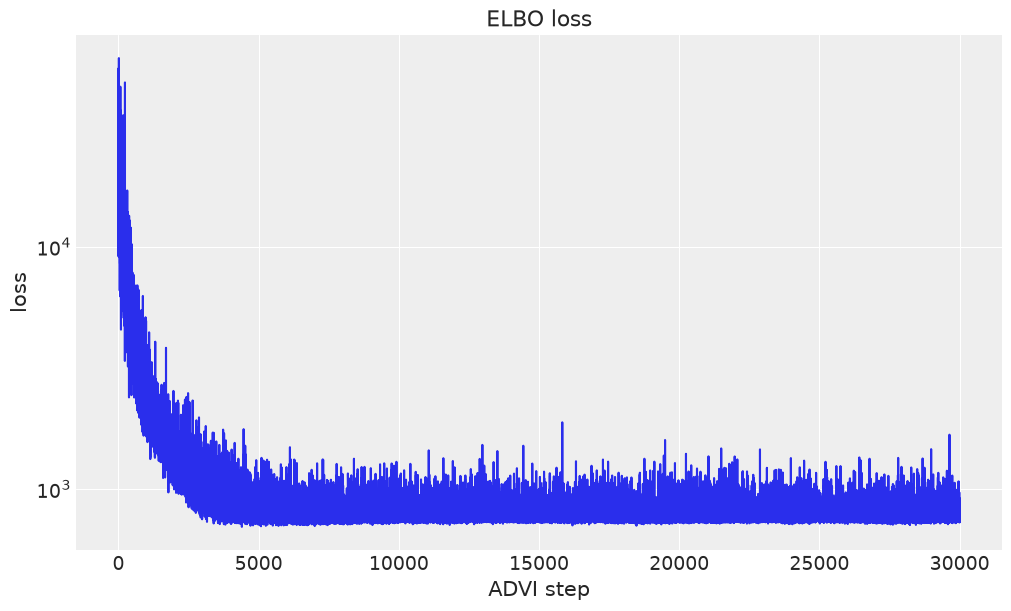

In [7]:
forecaster = Forecaster(
    model,
    y_train,
    covariates_train,
    optimizer=0.005,
    num_steps=NUM_STEPS,
    random_seed=SEED,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set(title="ELBO loss", xlabel="ADVI step", ylabel="loss", yscale="log")
plt.show()

## Forecast and evaluation

Passing the **full-horizon** covariates tells `forecast` how far past the training data
to predict: the horizon is the part of the covariate index that extends beyond the
training window. The result is an `InferenceData`-style tree whose `predictions` group
carries real `time_future` datetime coordinates.

In [8]:
train_pp_idata = forecaster.predict_in_sample(num_samples=NUM_SAMPLES, random_seed=SEED)
forecast_idata = forecaster.forecast(covariates, num_samples=NUM_SAMPLES, random_seed=SEED)

train_pp = train_pp_idata["posterior_predictive"]["obs"]
forecast = forecast_idata["predictions"]["forecast"]

train_scores = evaluate_forecast(train_pp, y_train)
test_scores = evaluate_forecast(forecast, y_test.rename({TIME_DIM: FUTURE_DIM}))
print("train:", train_scores)
print("test: ", test_scores)

train: {'mae': 0.302461289674996, 'rmse': 0.4100842414299849, 'crps': 0.22178288691263628, 'coverage': 0.9243197278911565}
test:  {'mae': 0.2324481513038304, 'rmse': 0.28312465187012326, 'crps': 0.1707058773637301, 'coverage': 1.0}


## Forecast visualization

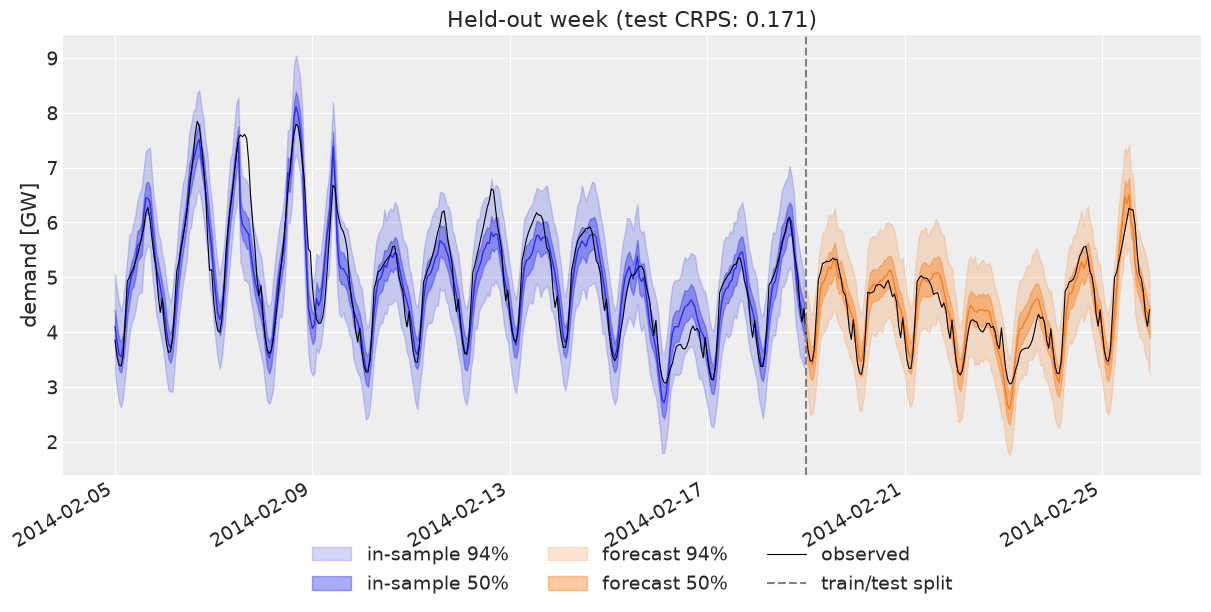

In [9]:
def plot_band(ax, samples, dim, color, label):
    """Median line and 50% / 94% quantile bands of a (chain, draw, time) array."""
    time_axis = samples[dim].values
    quantiles = samples.quantile([0.03, 0.25, 0.5, 0.75, 0.97], dim=("chain", "draw"))
    ax.fill_between(
        time_axis,
        quantiles.sel(quantile=0.03),
        quantiles.sel(quantile=0.97),
        color=color,
        alpha=0.2,
        label=f"{label} 94%",
    )
    ax.fill_between(
        time_axis,
        quantiles.sel(quantile=0.25),
        quantiles.sel(quantile=0.75),
        color=color,
        alpha=0.4,
        label=f"{label} 50%",
    )
    ax.plot(time_axis, quantiles.sel(quantile=0.5), color=color, lw=1)


ZOOM_HOURS = 24 * 21
train_pp_zoom = train_pp.isel({TIME_DIM: slice(-(ZOOM_HOURS - TEST_HOURS), None)})

fig, ax = plt.subplots(figsize=(12, 6))
plot_band(ax, train_pp_zoom, TIME_DIM, "C0", "in-sample")
plot_band(ax, forecast, FUTURE_DIM, "C1", "forecast")
zoom = demand.isel({TIME_DIM: slice(-ZOOM_HOURS, None)})
ax.plot(zoom[TIME_DIM].values, zoom.values, color="black", lw=0.8, label="observed")
ax.axvline(y_test[TIME_DIM].values[0], color="gray", ls="--", label="train/test split")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
title = f"Held-out week (test CRPS: {test_scores['crps']:.3f})"
ax.set(title=title, ylabel="demand [GW]")
fig.autofmt_xdate()
plt.show()

## The temperature response

Because the covariates are labeled, the fitted temperature effect can be read straight
off the posterior of `weight`: the response curve is
$w_\text{temp} \, z + w_\text{temp}^2 \, z^2$ over standardized temperature $z$.

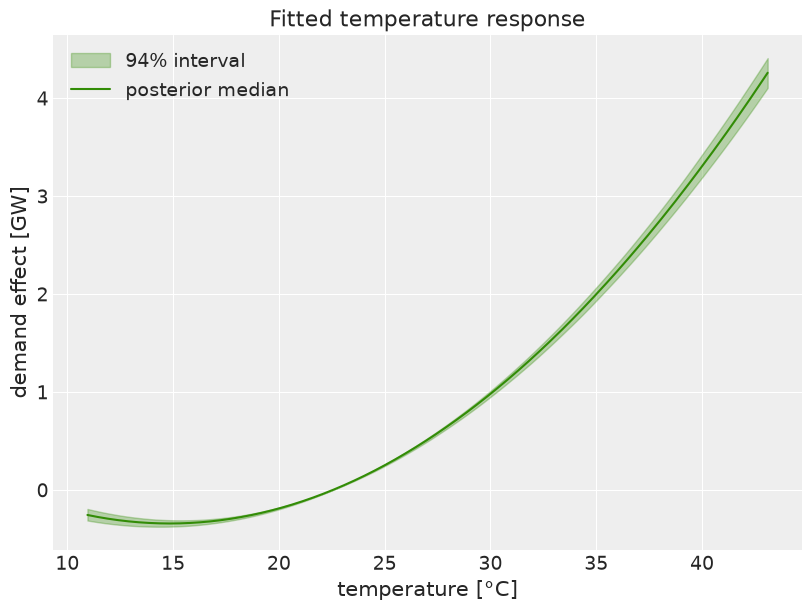

In [10]:
posterior = forecaster.draw_posterior(NUM_SAMPLES, random_seed=SEED)

temp_grid = np.linspace(float(temperature.min()), float(temperature.max()), 200)
grid_z = xr.DataArray(
    (temp_grid - temp_mean) / temp_scale,
    dims=("temperature_grid",),
    coords={"temperature_grid": temp_grid},
)
response = (
    posterior["weight"].sel(covariate="temperature") * grid_z
    + posterior["weight"].sel(covariate="temperature_sq") * grid_z**2
)
quantiles = response.quantile([0.03, 0.5, 0.97], dim=("chain", "draw"))

fig, ax = plt.subplots(figsize=(8, 6))
ax.fill_between(
    temp_grid,
    quantiles.sel(quantile=0.03),
    quantiles.sel(quantile=0.97),
    color="C2",
    alpha=0.3,
    label="94% interval",
)
ax.plot(temp_grid, quantiles.sel(quantile=0.5), color="C2", label="posterior median")
ax.legend()
ax.set(
    title="Fitted temperature response",
    xlabel="temperature [°C]",
    ylabel="demand effect [GW]",
)
plt.show()

The fitted curve reproduces the pattern from the scatter plot: a flat (even slightly
negative) effect at mild temperatures and a steep rise into the hot tail. The upstream
notebook refines exactly this piece with a Gaussian-process varying coefficient; the
rest of the workflow — `Forecaster`, `forecast`, `evaluate_forecast` — stays the same.

## References

- Upstream NumPyro notebook: <https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/electricity_forecast.ipynb>
- Juan Orduz, *Electricity Demand Forecast: Dynamic Time-Series Model*: <https://juanitorduz.github.io/electricity_forecast/>
- TensorFlow Probability, *Structural Time Series Modeling Case Studies*: <https://www.tensorflow.org/probability/examples/Structural_Time_Series_Modeling_Case_Studies_Atmospheric_CO2_and_Electricity_Demand>
- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*: <https://otexts.com/fpp2/scatterplots.html>